In [12]:
import pandas as pd

data = pd.read_csv('Titanic-Dataset.csv')
data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [13]:
	data.isnull().sum()


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [16]:

data['Age'] = data['Age'].fillna(data['Age'].median())    #Filling the missing values for age with the median value helps with reduce outliers
data.drop(columns=['Cabin'], inplace=True)   #since  much data is missing , it is best to drop it
data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])  # since just two values are null,  fill with the mode.

data.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [17]:
data.drop(columns=['PassengerId', 'Name', 'Ticket'], inplace=True)
# Removing irrelent columns that does not contribute greatly to research

In [18]:
data['Sex'] = data['Sex'].map({'female': 0, 'male': 1})
#convert categories to numbers for the better visualization

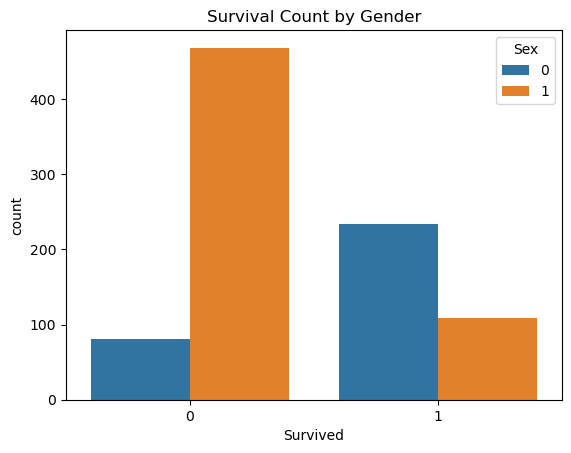

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Count of survivors vs non-survivors, split by Sex
#A Count Plot is the most direct way to see how many people survived versus how many did not, or to compare the number of male and female passengers
sns.countplot(x='Survived', hue='Sex', data=data)
plt.title('Survival Count by Gender')
plt.show()


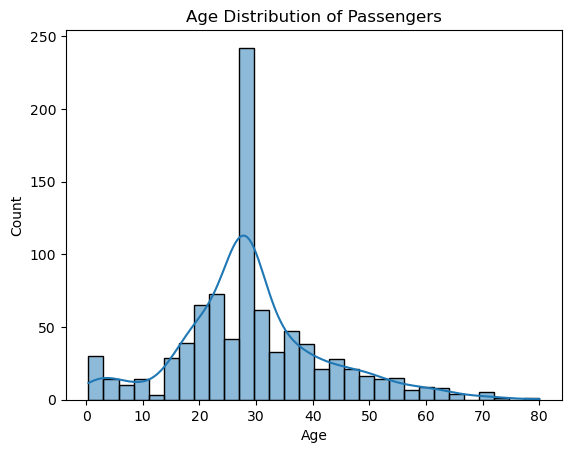

In [20]:
# Distribution of passenger ages
# Knowing the age majority that survived
sns.histplot(data['Age'], bins=30, kde=True)
plt.title('Age Distribution of Passengers')
plt.show()


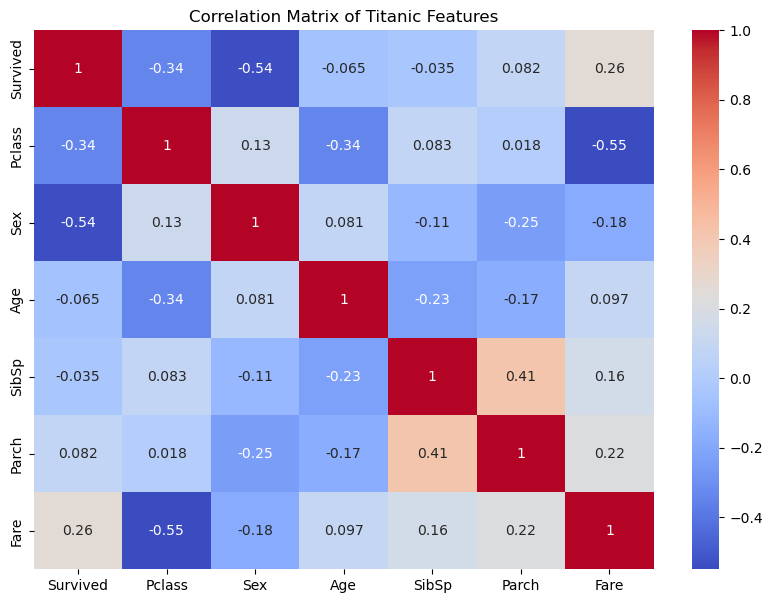

In [22]:
# Correlation heatmap
#A Heatmap allows you to see the correlation between all numerical columns at once, helping you identify which features (like Fare or Pclass) have the strongest link to survival
plt.figure(figsize=(10, 7))

sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm')

plt.title('Correlation Matrix of Titanic Features')
plt.show()
